In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
transactions = pd.read_excel(r'C:\Users\krist\MLMLML\tz_aton\intern_test_assignment\transactions_data.xlsx')

In [5]:
clients = pd.read_json(r'C:\Users\krist\MLMLML\tz_aton\intern_test_assignment\clients_data.json')

In [6]:
# Преобразование дат
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'], errors='coerce')

In [7]:
# Проверка результата
print("Пример преобразованных дат:")
print(transactions['transaction_date'].head())

Пример преобразованных дат:
0   2025-01-04 00:02:20
1   2025-03-10 17:16:50
2   2025-02-13 19:43:49
3   2025-03-02 03:14:10
4   2025-03-18 21:00:36
Name: transaction_date, dtype: datetime64[ns]


In [8]:
# Удаление строк с некорректными датами
transactions = transactions.dropna(subset=['transaction_date'])

In [9]:
# Ограничение диапазона дат
min_date = pd.Timestamp('2020-01-01')
max_date = pd.Timestamp('2025-12-31')
transactions = transactions[(transactions['transaction_date'] >= min_date) & (transactions['transaction_date'] <= max_date)]

In [10]:
# Проверка результата
print("Количество строк после фильтрации дат:")
print(len(transactions))

Количество строк после фильтрации дат:
8995


In [11]:
print("Пропущенные значения в транзакциях:")
print(transactions.isnull().sum())

print("\nПропущенные значения в клиентах:")
print(clients.isnull().sum())

Пропущенные значения в транзакциях:
transaction_id      430
client_id           182
transaction_date      0
service               0
amount              415
payment_method        0
city                  0
consultant            0
dtype: int64

Пропущенные значения в клиентах:
id              1
age           983
gender       3319
net_worth     475
dtype: int64


In [12]:
transactions = transactions.dropna(subset=['transaction_id', 'client_id', 'amount'])

In [13]:
transactions['transaction_date'] = transactions['transaction_date'].fillna(transactions['transaction_date'].mode()[0])
transactions['service'] = transactions['service'].fillna('Неизвестная услуга')
transactions['payment_method'] = transactions['payment_method'].fillna('Неизвестно')
transactions['city'] = transactions['city'].fillna('Неизвестный город')
transactions['consultant'] = transactions['consultant'].fillna('Неизвестный консультант')

In [14]:
print("Пропущенные значения после обработки:")
print(transactions.isnull().sum())

Пропущенные значения после обработки:
transaction_id      0
client_id           0
transaction_date    0
service             0
amount              0
payment_method      0
city                0
consultant          0
dtype: int64


In [15]:
# Проверка отрицательных значений в столбце amount
negative_amounts = transactions[transactions['amount'] < 0]
print("Отрицательные суммы транзакций:")
print(negative_amounts)

# Удаление строк с отрицательными суммами
transactions = transactions[transactions['amount'] >= 0]

Отрицательные суммы транзакций:
Empty DataFrame
Columns: [transaction_id, client_id, transaction_date, service, amount, payment_method, city, consultant]
Index: []


In [16]:
# Фильтрация некорректных услуг
invalid_services = ['Неизвестная услуга']
transactions = transactions[~transactions['service'].isin(invalid_services)]

# Фильтрация некорректных способов оплаты
invalid_payment_methods = ['Неизвестно']
transactions = transactions[~transactions['payment_method'].isin(invalid_payment_methods)]

In [17]:
# Проверка дубликатов
duplicate_rows = transactions[transactions.duplicated()]
print("Дубликаты в данных:")
print(duplicate_rows)

# Удаление дубликатов
transactions = transactions.drop_duplicates()

Дубликаты в данных:
Empty DataFrame
Columns: [transaction_id, client_id, transaction_date, service, amount, payment_method, city, consultant]
Index: []


In [18]:
top_services = transactions['service'].value_counts().head(5)
print("Топ-5 популярных услуг:")
print(top_services)

Топ-5 популярных услуг:
service
Инвестиционное консультирование    1774
Управление активами                1446
Финансовое планирование            1110
Налоговое планирование             1091
Структурирование капитала          1071
Name: count, dtype: int64


In [19]:
average_amount_by_city = transactions.groupby('city')['amount'].mean().sort_values(ascending=False)
print("Средняя сумма транзакций по городам:")
print(average_amount_by_city)

Средняя сумма транзакций по городам:
city
East Rachelmouth      56842.435977
Michellehaven         55345.596142
New Zacharyport       55313.820925
North Lauriebury      55006.752044
New Tommyborough      54457.820946
Port Michellemouth    54197.923278
Krystalland           54074.136178
Kaneburgh             53675.575555
Patelbury             53495.567756
Trevinoberg           53134.976305
South Andrew          51809.692559
Bondstad              51806.677406
North Melissaland     51765.985637
Erichaven             51361.574721
Lake Tina             51157.709337
Hamiltontown          50953.918367
Mayoberg              50748.126566
Port James            50716.882740
East Matthewmouth     50540.489491
Johnsonfort           50439.244834
Lake Arielmouth       50420.366241
Davidsonborough       50252.257670
Port Jordan           50117.451635
West Meredithhaven    49947.695882
North Emily           49925.098991
North Patrickport     49665.453171
Dannyburgh            49331.379214
Aprilstad    

In [20]:
total_revenue_by_service = transactions.groupby('service')['amount'].sum()
most_profitable_service = total_revenue_by_service.idxmax()
print(f"Услуга с наибольшей выручкой: {most_profitable_service}")

Услуга с наибольшей выручкой: Инвестиционное консультирование


In [21]:
payment_method_percentage = transactions['payment_method'].value_counts(normalize=True) * 100
print("Процент транзакций по способам оплаты:")
print(payment_method_percentage)

Процент транзакций по способам оплаты:
payment_method
Кредитная карта       44.346888
Банковский перевод    38.616759
Наличные              11.059766
Криптовалюта           5.976587
Name: proportion, dtype: float64


In [22]:
last_month = transactions['transaction_date'].max() - pd.Timedelta(days=30)
revenue_last_month = transactions[transactions['transaction_date'] >= last_month]['amount'].sum()
print(f"Выручка за последний месяц: {revenue_last_month}")

Выручка за последний месяц: 122385883.62235372


In [23]:
print("Столбцы в таблице transactions:")
print(transactions.columns)

Столбцы в таблице transactions:
Index(['transaction_id', 'client_id', 'transaction_date', 'service', 'amount',
       'payment_method', 'city', 'consultant'],
      dtype='object')


In [24]:
print(clients.columns)

Index(['id', 'age', 'gender', 'net_worth'], dtype='object')


In [25]:
clients.rename(columns = {'id': 'client_id'}, inplace = True)

In [26]:
print(clients.columns)

Index(['client_id', 'age', 'gender', 'net_worth'], dtype='object')


In [27]:
merged_data = pd.merge(transactions, clients, on='client_id', how='left')

# Удаление времени (оставляем только дату)
merged_data['transaction_date'] = merged_data['transaction_date'].dt.date

In [28]:
print("Первые строки объединенной таблицы: ")
print(merged_data.head())

Первые строки объединенной таблицы: 
                         transaction_id                             client_id  \
0  ff36597c-df41-44a0-9f46-6aa1fe615270  1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7   
1  822d5795-4f08-4a7a-9692-7f5863945bdf  900f7d6b-ee7f-49e6-ae9f-e5ea9e04ab4c   
2  56daf0d6-6f65-45a2-8895-8bcbcf0a7f51  9f6d2dfb-20af-4329-8383-7bd7b14f2480   
3  b40616d1-176c-4b07-9b7f-3f313440ccf6  27c2994f-97a1-4ff1-a9e4-bc52db0f603a   
4  5fcd81cd-379c-4dc7-a70e-f4ace842f3df  9f29e688-86ca-46f2-bfdd-0a9d33013f47   

  transaction_date                          service        amount  \
0       2025-01-04        Структурирование капитала  55838.059789   
1       2025-02-21  Инвестиционное консультирование  85575.773285   
2       2025-03-11           Налоговое планирование   5590.175424   
3       2025-01-06              Управление активами  84945.352622   
4       2025-01-27          Финансовое планирование  29785.105420   

       payment_method               city       consultant   a

In [29]:
# Проверка количества строк
print(f"Количество строк в объединенной таблице: {len(merged_data)}")
print(f"Количество строк в таблице: {len(transactions)}")
print(f"Количество строк в таблице: {len(clients)}")

# Проверка наличия дубликатов
print("Дубликаты в объединенной таблице:")
print(merged_data.duplicated().sum())

Количество строк в объединенной таблице: 6492
Количество строк в таблице: 6492
Количество строк в таблице: 9799
Дубликаты в объединенной таблице:
0


In [30]:
def categorize_net_worth(net_worth):
    if net_worth < 100000:
        return 'Низкий капитал'
    elif 100000 <= net_worth <= 1000000:
        return 'Средний капитал'
    else:
        return 'Высокий капитал'
merged_data['net_worth_category'] = merged_data['net_worth'].apply(categorize_net_worth)

In [31]:
#Анализ выручки по категориям
revenue_by_category = merged_data.groupby('net_worth_category')['amount'].sum()
revenue_by_category_formatted = revenue_by_category.map('{:,.0f}'.format)
print("Выручка по категориям клиентов:")
print(revenue_by_category_formatted)

Выручка по категориям клиентов:
net_worth_category
Высокий капитал    264,618,843
Низкий капитал       5,106,376
Средний капитал     51,929,059
Name: amount, dtype: object


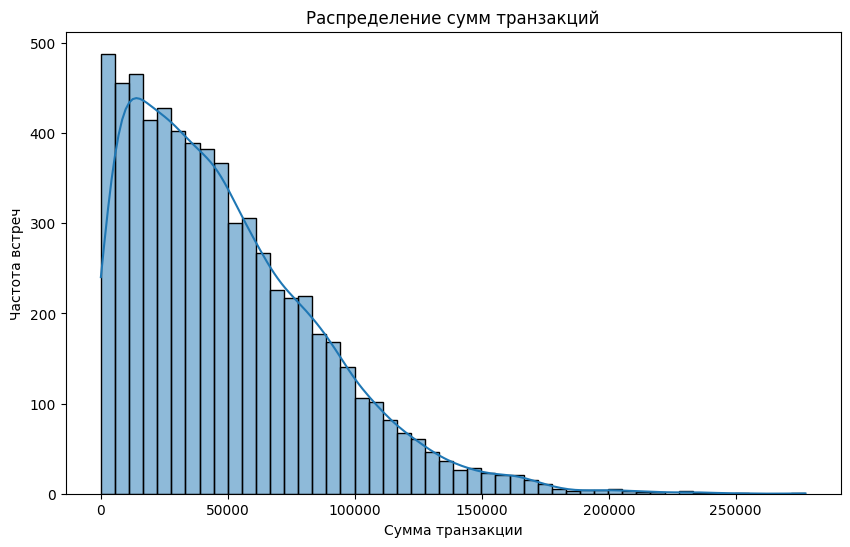

In [32]:
# Визуалиация данных
# Распределение сумм транзакций по частоте встречи в данных
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(merged_data['amount'], bins=50, kde=True)
plt.title('Распределение сумм транзакций')
plt.xlabel('Сумма транзакции')
plt.ylabel('Частота встреч')
plt.show()

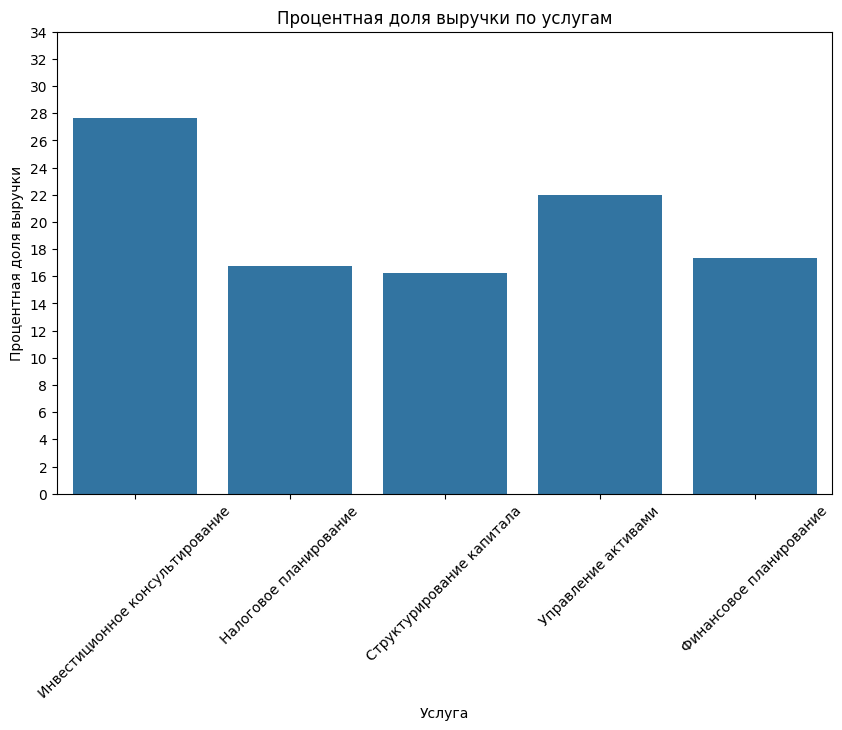

In [33]:
# Диаграмма выручки по услугам
# Решил сделать по проценту выручки, потому что так понятнее визуализация
total_revenue = total_revenue_by_service.sum()
revenue_percentage_by_service = total_revenue_by_service.apply(lambda x: (x / total_revenue) * 100)
plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_percentage_by_service.index, y=revenue_percentage_by_service.values)
plt.title('Процентная доля выручки по услугам')
plt.xlabel('Услуга')
plt.ylabel('Процентная доля выручки')
plt.yticks(range(0, 35, 2))
plt.xticks(rotation=45)
plt.show()

C:\Users\krist\AppData\Local\Temp\ipykernel_8892\2173292426.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_vs_amount_grouped = merged_data.groupby('age_group')['amount'].mean()


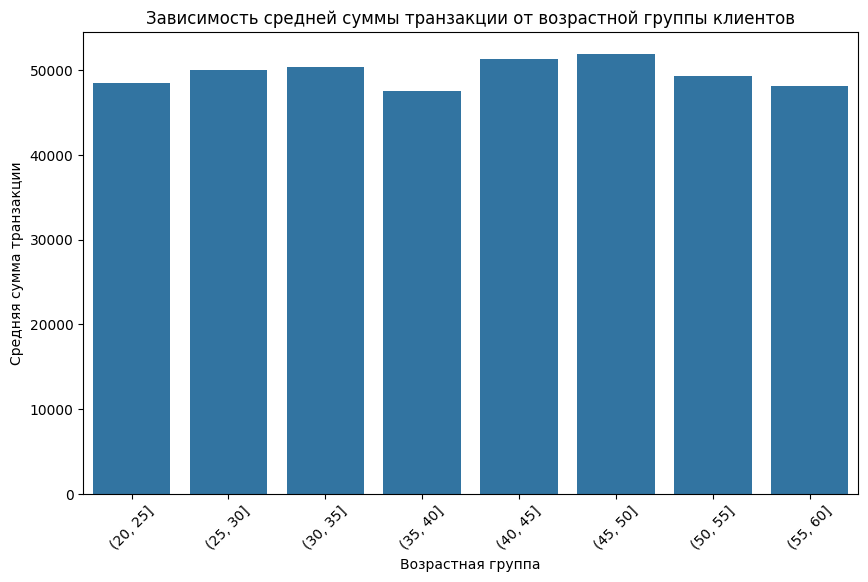

In [34]:
# Группировка данных по возрастным диапазонам
merged_data['age_group'] = pd.cut(merged_data['age'], bins=range(20, 65, 5))

# Расчет средней суммы транзакций для каждой возрастной группы
age_vs_amount_grouped = merged_data.groupby('age_group')['amount'].mean()

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x=age_vs_amount_grouped.index, y=age_vs_amount_grouped.values)
plt.title('Зависимость средней суммы транзакции от возрастной группы клиентов')
plt.xlabel('Возрастная группа')
plt.ylabel('Средняя сумма транзакции')
plt.xticks(rotation=45)
plt.show()

In [35]:
# Прогнозирование спроса на следующий месяц
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from datetime import timedelta
import lightgbm as lgb
from catboost import CatBoostRegressor

In [36]:
transactions = pd.read_excel(r'C:\Users\krist\MLMLML\tz_aton\intern_test_assignment\transactions_data.xlsx')
clients = pd.read_json(r'C:\Users\krist\MLMLML\tz_aton\intern_test_assignment\clients_data.json')

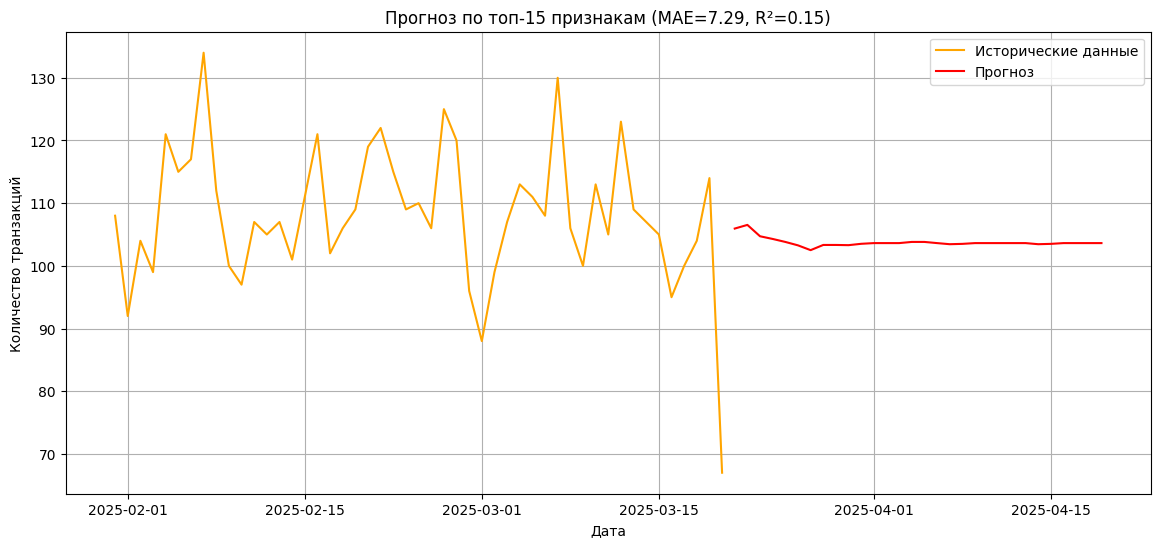

In [37]:
merged_data = pd.merge(transactions, clients, left_on='client_id', right_on='id', how='left')

merged_data['transaction_date'] = pd.to_datetime(merged_data['transaction_date'], errors='coerce')
merged_data = merged_data.dropna(subset=['transaction_date'])
merged_data['date'] = merged_data['transaction_date'].dt.date

# === 2. Агрегация по дням ===
daily_data = merged_data.groupby('date').agg({
    'transaction_id': 'count',
    'amount': 'sum',
    'age': 'mean',
    'net_worth': 'mean',
    'gender': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'service': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'payment_method': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'city': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'consultant': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
}).rename(columns={'transaction_id': 'transaction_count'})

daily_data.index = pd.to_datetime(daily_data.index)
daily_data['day_of_week'] = daily_data.index.dayofweek
daily_data['month'] = daily_data.index.month
daily_data['year'] = daily_data.index.year
daily_data['is_weekend'] = daily_data.index.dayofweek.isin([5, 6]).astype(int)

daily_data['rolling_mean_7'] = daily_data['transaction_count'].rolling(7).mean()
daily_data['rolling_mean_30'] = daily_data['transaction_count'].rolling(30).mean()
for i in [1, 7, 30]:
    daily_data[f'lag_{i}'] = daily_data['transaction_count'].shift(i)

daily_data = daily_data.dropna()
daily_data_encoded = pd.get_dummies(daily_data, columns=['service', 'payment_method', 'city', 'consultant', 'gender'])

# === 3. Обучение модели по топ-15 признакам ===
X = daily_data_encoded.drop(columns='transaction_count')
y = daily_data_encoded['transaction_count']

rf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=10, min_samples_leaf=2)
rf.fit(X, y)
top_features = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15).index.tolist()

X_top = X[top_features]
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)

best_rf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=10, min_samples_leaf=2)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# === 4. Autoregressive прогноз на 30 дней ===
last_date = daily_data.index[-1]
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=30, freq='D')
future_predictions = []
history = daily_data.copy()

# Сохраняем последние значения категориальных признаков
last_vals = {
    'age': history['age'].iloc[-1],
    'net_worth': history['net_worth'].iloc[-1],
    'amount': history['amount'].iloc[-1],
}
for col in top_features:
    if col not in ['amount', 'lag_1', 'lag_7', 'rolling_mean_7', 'age', 'net_worth', 'day_of_week', 'is_weekend', 'month']:
        last_vals[col] = 1  # для one-hot кодов

# Прогнозируем каждый день
for date in future_dates:
    row = {
        'amount': history['amount'].iloc[-7:].mean(),
        'lag_1': history['transaction_count'].iloc[-1],
        'lag_7': history['transaction_count'].iloc[-7],
        'rolling_mean_7': history['transaction_count'].iloc[-7:].mean(),
        'net_worth': last_vals['net_worth'],
        'age': last_vals['age'],
        'day_of_week': date.dayofweek,
        'is_weekend': int(date.dayofweek in [5, 6]),
        'month': date.month
    }
    for col in top_features:
        if col not in row:
            row[col] = last_vals.get(col, 0)

    row_df = pd.DataFrame([row])[top_features]
    pred = best_rf.predict(row_df)[0]
    future_predictions.append(pred)
    history = pd.concat([history, pd.DataFrame({'transaction_count': [pred], 'amount': [row['amount']]}, index=[date])])

# === 5. Визуализация результата ===
future_df = pd.DataFrame({'predicted_transaction_count': future_predictions}, index=future_dates)

plt.figure(figsize=(14, 6))
plt.plot(daily_data.index, daily_data['transaction_count'], label='Исторические данные', color='orange')
plt.plot(future_df.index, future_df['predicted_transaction_count'], label='Прогноз', color='red')
plt.title(f"Прогноз по топ-15 признакам (MAE={mae:.2f}, R²={r2:.2f})")
plt.xlabel("Дата")
plt.ylabel("Количество транзакций")
plt.legend()
plt.grid(True)
plt.show()